In [1]:
import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path

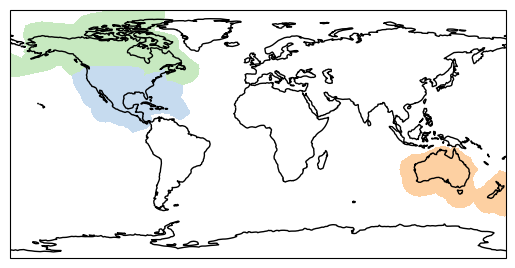

In [2]:
# Load in regional shapefile notebook
%run regions.ipynb

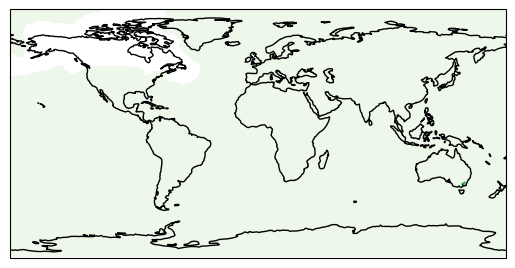

In [131]:
# Open test dataset to determine how to mask values
ds_test = xr.open_dataset('/glade/work/ekeefe/research_code/gfas4htap_fire_emissions/gfas4htap-moz_ALKNIT_bb_2003-2023_f09_c20260306.nc')

# Change names of coordinates to match between datasets
renamed_BNA = BNA.rename({'latitude':'lat', 'longitude':'lon'})

# Change geographic coordinates in both datasets to be correct for plotting
renamed_BNA = renamed_BNA.assign_coords(lon=(((renamed_BNA.lon + 180) % 360) - 180)).sortby('lon')
ds_test = ds_test.assign_coords(lon=(((ds_test.lon + 180) % 360) - 180)).sortby('lon')
BNA_mask = renamed_BNA.interp({'lat':ds_test.lat, 'lon':ds_test.lon}, method = 'nearest')

# Apply mask to test dataset
ds_masked = ds_test.where(BNA_mask == 0)

# Map the masked emissions just to see if it worked
proj = ccrs.PlateCarree()
fig = plt.figure()
ax = plt.axes(projection = proj)
ax.coastlines()

da_plot = ds_masked.isel(time=0)
c = ax.contourf(ds_masked.lon, ds_masked.lat, da_plot.bb, transform=ccrs.PlateCarree(), cmap=matplotlib.cm.Greens)

In [5]:
# Align coordinate names and values to allow masking
renamed_BNA = BNA.rename({'latitude':'lat', 'longitude':'lon'}) # Aligning coordinate names
renamed_TNA = TNA.rename({'latitude':'lat', 'longitude':'lon'})
renamed_ANZ = ANZ.rename({'latitude':'lat', 'longitude':'lon'})

renamed_BNA = renamed_BNA.assign_coords(lon=(((renamed_BNA.lon + 180) % 360) - 180)).sortby('lon') # Changing longitude range to allow for mapping
renamed_TNA = renamed_TNA.assign_coords(lon=(((renamed_TNA.lon + 180) % 360) - 180)).sortby('lon')
renamed_ANZ = renamed_ANZ.assign_coords(lon=(((renamed_ANZ.lon + 180) % 360) - 180)).sortby('lon')

# Loop through each species-specific dataset and mask out each region
p = Path('/glade/work/ekeefe/research_code/gfas4htap_fire_emissions/')
BNA_masked_list = []
TNA_masked_list = []
ANZ_masked_list = []

for file in p.iterdir(): # Begin loop
    ds = xr.open_dataset(file)
    ds_corr = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180)).sortby('lon') # Correct longitude scale to allow for mapping
    for mask in [renamed_BNA, renamed_TNA, renamed_ANZ]: # Loop through regional datasets
        reg_mask = mask.interp({'lat':ds_corr.lat, 'lon':ds_corr.lon}, method = 'nearest')
        ds_mask_reg = ds_corr.where(reg_mask == 0)
        if 'BNA' in str(mask):
            BNA_masked_list.append(ds_mask_reg)
        elif 'TNA' in str(mask):
            TNA_masked_list.append(ds_mask_reg)
        else:
            ANZ_masked_list.append(ds_mask_reg)

In [2]:
# Notes:
# lev starts at 0, hectopascals
# hybrid sigma coordinates
# first approx, take up to ten levels